# Sparkle V2 — Fase 2: Modelado y Optimización

**Proyecto:** Sparkle V2 — Módulo de detección de desatención/fatiga en estudiantes
**Dataset:** DAiSEE (Gupta *et al.*, 2016) — mirror Kaggle `olgaparfenova/daisee`
**Entorno de ejecución:** Google Colab (GPU T4)
**Punto de partida:** Baseline LSTM Fase 1 → Test accuracy **36,9%** / F1 macro **0,347**, por debajo del clasificador trivial (**45,6%**).
**Objetivo:** re-entrenar y optimizar el modelo con el set de features enriquecido (`features_v2`) hasta superar con claridad el baseline trivial y aproximarse al rango reportado en la literatura para DAiSEE (~47% accuracy; Das y Dev, 2025).

Este notebook implementa el `Plan_Implementacion_Fase2_Modelado.md` de punta a punta: **Sprint 0** (carga) → **Sprint 1** (consolidación: NaN, deltas, normalización) → **Sprint 2** (arquitectura) → **Sprint 3** (desbalance) → **Sprint 4** (entrenamiento, métricas, ablation) → **Sprint 5** (export Edge AI, opcional).

> **Nota de verificación:** el loader, la limpieza de NaN, el cálculo de deltas, el scaler, el class weighting y la arquitectura BiGRU de este notebook fueron probados contra un clip real de `features_v2/Train` (mismo esquema `.npz` documentado abajo) antes de entregarse. Se corrigieron dos detalles del plan original:
> 1. **`interpolate_sequence`** ahora aplica `ffill().bfill()` explícito después de la interpolación lineal (la interpolación sola no cubre NaN en los bordes de la secuencia, como ya advertía el texto del plan).
> 2. **Export a TFLite (Sprint 5)** usa un modelo de exportación con `batch_size` fijo, porque la conversión directa de una `Bidirectional(GRU)` con batch dinámico falla en TFLite (`TensorListReserve requires element_shape to be static`) a menos que se habiliten Flex ops (que agregan una dependencia pesada al runtime). Con batch fijo, el `.tflite` resultante usa solo operadores nativos (`TFLITE_BUILTINS`), ideal para un despliegue Edge/extensión de navegador liviano.

## Sprint 0 — Setup del entorno y carga de datos

### 0.0 Estado real de los datos de entrada

El pipeline `Sparkle_V2_Fase2_3_v2_MAR_Blendshapes.ipynb` ya generó, por clip, un archivo `.npz` en `features_v2/{Train,Validation,Test}/` con esta estructura (confirmada contra un clip real: `sequence` shape `(60, 22)` float64, mas `feature_names`, `boredom`, `engagement`, `confusion`, `frustration` escalares):

```
sequence        → np.ndarray  shape (60, 22)   # 60 cuadros × 22 features
feature_names   → lista de 22 strings
boredom         → int 0..3    # etiqueta cruda
engagement, confusion, frustration → int 0..3
```

Las **22 features por cuadro**:

| # | Grupo | Variables |
|---|---|---|
| 1–3 | Apertura ocular | `ear_avg`, `ear_left`, `ear_right` |
| 4–5 | Orientación de cabeza | `yaw`, `pitch` (grados) |
| 6 | Boca | `mar` (Mouth Aspect Ratio) |
| 7–8 | Parpadeo (blendshapes) | `eyeBlinkLeft`, `eyeBlinkRight` |
| 9–10 | Entrecerrar ojos | `eyeSquintLeft`, `eyeSquintRight` |
| 11–18 | Dirección de mirada (gaze) | `eyeLookInLeft/Right`, `eyeLookOutLeft/Right`, `eyeLookUpLeft/Right`, `eyeLookDownLeft/Right` |
| 19–21 | Cejas | `browDownLeft`, `browDownRight`, `browInnerUp` |
| 22 | Mandíbula | `jawOpen` |

> Los `.npz` contienen **22 features base** (nivel/posición). Los **deltas** (velocidad de cambio) se derivan en el **Sprint 1** a partir de estas 22 columnas — es una transformación determinística, no requiere re-procesar video.

**Target (Fase 1, sección 2.3):** `Boredom` colapsado a 3 niveles — 0 Atento, 1 Desatención leve, 2 Desatención marcada ({2,3}). **Alerta de diseño:** la partición **Validation está desalineada** respecto de Train/Test (más desatención marcada). Por eso la selección de modelo se hace con **macro-F1** y el número que se reporta en la tesis es siempre el de **Test**.

### 0.1 Runtime y dependencias

In [2]:
# Colab: Runtime -> Change runtime type -> GPU (T4)
!pip install -q scikit-learn tensorflow imbalanced-learn focal-loss

import os, glob, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/SparkleV2'
FEATURES_DIR = f'{PROJECT_DIR}/features_v2'
OUT_DIR      = f'{PROJECT_DIR}/dataset_final'      # consolidado de la Fase 2
CKPT_DIR     = f'{PROJECT_DIR}/checkpoints'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive


### 0.2 Loader: de `.npz` por clip a tensores por split

In [3]:
N_FRAMES = 60

def collapse_boredom(b):
    # 0->Atento, 1->leve, {2,3}->marcada
    return 0 if b == 0 else (1 if b == 1 else 2)

def load_split(split):
    """Devuelve X (N,60,22), y (N,), ids (N,) y la lista de feature_names."""
    files = sorted(glob.glob(f'{FEATURES_DIR}/{split}/*.npz'))
    X, y, ids = [], [], []
    feat_names = None
    n_bad_shape = 0
    for f in files:
        d = np.load(f, allow_pickle=True)
        seq = d['sequence'].astype(np.float32)           # (60, 22)
        if seq.shape != (N_FRAMES, 22):
            n_bad_shape += 1
            continue                                      # descarta clips mal formados
        if feat_names is None:
            feat_names = list(d['feature_names'])
        X.append(seq)
        y.append(collapse_boredom(int(d['boredom'])))
        ids.append(os.path.splitext(os.path.basename(f))[0])
    if n_bad_shape:
        print(f'  [{split}] {n_bad_shape} clips descartados por shape inesperado')
    return np.stack(X), np.array(y, dtype=np.int64), np.array(ids), feat_names

X_train_raw, y_train, id_train, FEATS = load_split('Train')
X_val_raw,   y_val,   id_val,   _     = load_split('Validation')
X_test_raw,  y_test,  id_test,  _     = load_split('Test')

for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = np.bincount(y, minlength=3) / len(y)
    print(f'{name}: {len(y)} clips | dist {dist.round(3)}')

Train: 4959 clips | dist [0.447 0.306 0.247]
Val: 1429 clips | dist [0.312 0.263 0.425]
Test: 1638 clips | dist [0.456 0.317 0.227]


**Compuerta S0:** las proporciones impresas deben aproximarse a Train ≈ [0.45, 0.31, 0.25], Test ≈ [0.46, 0.32, 0.23], Val ≈ [0.31, 0.26, 0.43]. Si no coinciden, revisar el mapeo `collapse_boredom` o clips faltantes.

In [4]:
# Compuerta S0 (assert suave: solo avisa, no interrumpe la ejecución)
expected = {'Train': [0.45, 0.31, 0.25], 'Validation': [0.31, 0.26, 0.43], 'Test': [0.46, 0.32, 0.23]}
observed = {
    'Train': np.bincount(y_train, minlength=3) / len(y_train),
    'Validation': np.bincount(y_val, minlength=3) / len(y_val),
    'Test': np.bincount(y_test, minlength=3) / len(y_test),
}
for split, exp in expected.items():
    diff = np.abs(np.array(exp) - observed[split]).max()
    status = 'OK' if diff < 0.05 else 'REVISAR'
    print(f'{split}: esperado {exp} | observado {observed[split].round(3)} | max_diff={diff:.3f} [{status}]')

Train: esperado [0.45, 0.31, 0.25] | observado [0.447 0.306 0.247] | max_diff=0.004 [OK]
Validation: esperado [0.31, 0.26, 0.43] | observado [0.312 0.263 0.425] | max_diff=0.005 [OK]
Test: esperado [0.46, 0.32, 0.23] | observado [0.456 0.317 0.227] | max_diff=0.004 [OK]


## Sprint 1 — Consolidación de datos

Tres sub-tareas en orden estricto: **(1)** tratar NaN → **(2)** derivar deltas → **(3)** normalizar. Los deltas deben calcularse sobre secuencias ya interpoladas (sin NaN), y la normalización se ajusta *después* de tener el set final de columnas y *solo* con Train.

### 1.1 Tratamiento de valores faltantes (NaN)

**Origen de los NaN:** cuadros donde MediaPipe no detectó rostro (fila completa a NaN) o donde un denominador geométrico se anuló (EAR/MAR aislados). Blendshapes y gaze pueden introducir NaN adicionales cuando el rostro está muy oblicuo.

**Estrategia:**
1. Interpolación **lineal por columna, dentro de cada secuencia** (nunca entre clips).
2. Relleno de bordes con `ffill`/`bfill` (la interpolación lineal no extrapola más allá del primer/último valor conocido, así que se aplica explícitamente después).
3. Si tras esto queda alguna columna 100% NaN en un clip, se rellena con la **mediana de esa feature en Train**.
4. **Descarte de clips** con más de **30%** de cuadros con algún NaN.

In [5]:
def interpolate_sequence(seq):
    """seq: (60, F). Interpola por columna dentro de la secuencia y rellena bordes."""
    df = pd.DataFrame(seq)
    df = df.interpolate(method='linear', axis=0, limit_direction='both')
    df = df.ffill().bfill()   # cubre NaN residuales en los bordes (la interpolación lineal no extrapola)
    return df.values.astype(np.float32)

def clean_split(X, y, ids, nan_frame_thresh=0.30, train_medians=None):
    keep, X_clean = [], []
    for i in range(len(X)):
        frac_nan_frames = np.isnan(X[i]).any(axis=1).mean()
        if frac_nan_frames > nan_frame_thresh:
            continue                                  # descarta clip
        seq = interpolate_sequence(X[i])
        if np.isnan(seq).any() and train_medians is not None:
            idx = np.where(np.isnan(seq))
            seq[idx] = np.take(train_medians, idx[1]) # fallback: mediana de Train
        X_clean.append(seq); keep.append(i)
    keep = np.array(keep)
    return np.stack(X_clean), y[keep], ids[keep]

# Medianas por feature calculadas SOLO en Train (ignorando NaN)
train_medians = np.nanmedian(X_train_raw.reshape(-1, X_train_raw.shape[-1]), axis=0)

X_train, y_train, id_train = clean_split(X_train_raw, y_train, id_train, train_medians=train_medians)
X_val,   y_val,   id_val   = clean_split(X_val_raw,   y_val,   id_val,   train_medians=train_medians)
X_test,  y_test,  id_test  = clean_split(X_test_raw,  y_test,  id_test,  train_medians=train_medians)

assert not np.isnan(X_train).any(), "Quedan NaN en Train"
assert not np.isnan(X_val).any(),   "Quedan NaN en Validation"
assert not np.isnan(X_test).any(),  "Quedan NaN en Test"
print("NaN residuales:", np.isnan(X_train).sum(), np.isnan(X_val).sum(), np.isnan(X_test).sum())
print("Clips retenidos -> Train:", len(y_train), "| Val:", len(y_val), "| Test:", len(y_test))

NaN residuales: 0 0 0
Clips retenidos -> Train: 4958 | Val: 1429 | Test: 1638


### 1.2 Derivación de deltas (velocidad de cambio → inquietud/fidgeting)

Los deltas son la primera derivada temporal `Δ_t = x_t − x_{t−1}`, con `Δ_0 = 0`. Capturan **movimiento** que el valor absoluto no expresa.

**Opción A (recomendada para arrancar):** deltas sobre un subconjunto curado de 10 señales dinámicamente informativas → 22 + 10 = **32 features**. La Opción B (deltas sobre las 22 → 44 features) queda para el ablation del Sprint 4.

In [6]:
# Subconjunto curado para deltas (Opción A): apertura ocular, pose, boca, gaze, parpadeo
DELTA_FEATURES = ['ear_avg', 'yaw', 'pitch', 'mar', 'jawOpen',
                  'eyeBlinkLeft', 'eyeBlinkRight',
                  'eyeLookInLeft', 'eyeLookOutLeft', 'browInnerUp']
delta_idx = [FEATS.index(f) for f in DELTA_FEATURES]

def add_deltas(X, idx):
    d = np.zeros_like(X[:, :, idx])
    d[:, 1:, :] = np.diff(X[:, :, idx], axis=1)     # Delta_t; Delta_0 = 0
    return np.concatenate([X, d], axis=-1)

X_train = add_deltas(X_train, delta_idx)
X_val   = add_deltas(X_val,   delta_idx)
X_test  = add_deltas(X_test,  delta_idx)

FEATS_FULL = FEATS + [f'd_{f}' for f in DELTA_FEATURES]
print("Dim final de features:", X_train.shape[-1], "->", FEATS_FULL)
assert X_train.shape[-1] == 32

Dim final de features: 32 -> [np.str_('ear_avg'), np.str_('ear_left'), np.str_('ear_right'), np.str_('yaw'), np.str_('pitch'), np.str_('mar'), np.str_('eyeBlinkLeft'), np.str_('eyeBlinkRight'), np.str_('eyeSquintLeft'), np.str_('eyeSquintRight'), np.str_('eyeLookInLeft'), np.str_('eyeLookOutLeft'), np.str_('eyeLookUpLeft'), np.str_('eyeLookDownLeft'), np.str_('eyeLookInRight'), np.str_('eyeLookOutRight'), np.str_('eyeLookUpRight'), np.str_('eyeLookDownRight'), np.str_('browDownLeft'), np.str_('browDownRight'), np.str_('browInnerUp'), np.str_('jawOpen'), 'd_ear_avg', 'd_yaw', 'd_pitch', 'd_mar', 'd_jawOpen', 'd_eyeBlinkLeft', 'd_eyeBlinkRight', 'd_eyeLookInLeft', 'd_eyeLookOutLeft', 'd_browInnerUp']


### 1.3 Normalización

Las escalas son heterogéneas — EAR/MAR ~0,1–0,6, ángulos yaw/pitch en grados (~−90..90), blendshapes en [0,1], deltas centrados en 0. Se aplica **estandarización por feature** (`StandardScaler`), **ajustada exclusivamente sobre Train**. Se ajusta *después* de agregar deltas, para que el scaler cubra las 32 columnas.

In [7]:
from sklearn.preprocessing import StandardScaler
import joblib

def fit_scaler(X_train):
    F = X_train.shape[-1]
    scaler = StandardScaler().fit(X_train.reshape(-1, F))   # (N*60, F)
    return scaler

def apply_scaler(X, scaler):
    N, T, F = X.shape
    return scaler.transform(X.reshape(-1, F)).reshape(N, T, F).astype(np.float32)

scaler = fit_scaler(X_train)
X_train = apply_scaler(X_train, scaler)
X_val   = apply_scaler(X_val,   scaler)
X_test  = apply_scaler(X_test,  scaler)

joblib.dump(scaler, f'{OUT_DIR}/scaler_v2.joblib')          # necesario para producción/Edge
print("Scaler ajustado y aplicado. mean~0:", X_train.reshape(-1,32).mean(0)[:3].round(3),
      "| std~1:", X_train.reshape(-1,32).std(0)[:3].round(3))

Scaler ajustado y aplicado. mean~0: [-0. -0. -0.] | std~1: [1. 1. 1.]


### 1.4 Persistencia del dataset consolidado

In [8]:
np.savez_compressed(
    f'{OUT_DIR}/dataset_v2.npz',
    X_train=X_train, y_train=y_train, id_train=id_train,
    X_val=X_val,     y_val=y_val,     id_val=id_val,
    X_test=X_test,   y_test=y_test,   id_test=id_test,
    feature_names=np.array(FEATS_FULL),
)
print("Consolidado guardado. Shapes:", X_train.shape, X_val.shape, X_test.shape)

Consolidado guardado. Shapes: (4958, 60, 32) (1429, 60, 32) (1638, 60, 32)


**Compuerta S1:** 0 NaN residuales en los tres splits; scaler serializado; `dataset_v2.npz` re-cargable. A partir de aquí el modelado no vuelve a tocar los `.npz` por clip.

## Sprint 2 — Arquitectura del modelo

### 2.1 Diagnóstico y principio de diseño

El baseline de Fase 1 (2 capas LSTM de 64 y 32 unidades) falló por **falta de señal en las features**, no por la arquitectura. Con features más ricas (32 columnas, con gaze, blendshapes y dinámica), el principio rector cambia:

1. **Re-confirmar señal antes de modelar en profundidad** con un baseline *no temporal* fuerte.
2. **Reducir capacidad, no aumentarla** — con ~4.800 secuencias de entrenamiento, una LSTM de 64+32 sobreajusta fácil.
3. **Preferir GRU sobre LSTM en datos escasos.**

### 2.2 Paso previo obligatorio — baseline no temporal (re-diagnóstico)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

def summary_features(X):
    # media, std, min, max, y percentiles por feature -> vector por clip
    return np.concatenate([X.mean(1), X.std(1), X.min(1), X.max(1),
                           np.percentile(X, 25, 1), np.percentile(X, 75, 1)], axis=1)

Xtr_s, Xva_s, Xte_s = map(summary_features, [X_train, X_val, X_test])

baseline_results = {}
for name, clf in [('LogReg', LogisticRegression(max_iter=2000, class_weight='balanced')),
                  ('RandomForest', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', random_state=SEED))]:
    clf.fit(Xtr_s, y_train)
    p = clf.predict(Xte_s)
    acc, f1m = accuracy_score(y_test, p), f1_score(y_test, p, average='macro')
    baseline_results[name] = {'acc': acc, 'f1_macro': f1m}
    print(f'{name}: acc={acc:.3f} | f1_macro={f1m:.3f}')

LogReg: acc=0.436 | f1_macro=0.414
RandomForest: acc=0.449 | f1_macro=0.365


> Interpretación: en Fase 1 estos modelos daban acc ~ 0,37–0,40 (bajo el trivial). Si ahora superan 0,456, el enriquecimiento de features funcionó y la parte temporal solo debe igualarlos o superarlos. Es el resultado más importante para la narrativa de la tesis.

### 2.3 Arquitectura recomendada — GRU compacta y regularizada

In [10]:
def build_gru(input_shape, n_classes=3, units=32, dropout=0.4, l2=1e-4, lr=5e-4):
    reg = keras.regularizers.l2(l2)
    inp = keras.Input(shape=input_shape)                      # (60, F)
    # Masking es opcional: todos los clips tienen 60 cuadros (sin padding). Se puede
    # omitir; se incluye solo si más adelante se usa padding o time-masking (aug).
    x = layers.Masking(mask_value=0.0)(inp)
    x = layers.Bidirectional(
            layers.GRU(units, dropout=dropout, recurrent_dropout=0.2,
                       kernel_regularizer=reg))(x)            # 1 capa BiGRU
    x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),    # clip de gradiente
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])
    return model

model = build_gru(X_train.shape[1:])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60, 32)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 60, 32)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 60)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     12,672 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      1,040 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,019 (54.76 KB)

 Trainable params: 13,891 (54.26 KB)

 Non-trainable params: 128 (512.00 B)

**Ajustes clave respecto del baseline de Fase 1:**

| Aspecto | Baseline v1 | Propuesta v2 | Motivo |
|---|---|---|---|
| Capas recurrentes | 2 (LSTM 64+32) | 1 (BiGRU 32) | Menos capacidad → menos sobreajuste |
| Celda | LSTM | GRU (bidireccional) | Mejor con pocos datos; ve la secuencia completa |
| Dropout | 0,3 | 0,4 + `recurrent_dropout` 0,2 | Regularización más fuerte |
| Regularización L2 | — | 1e-4 | Penaliza pesos grandes |
| Learning rate | (~1e-3) | 5e-4 + `ReduceLROnPlateau` | Convergencia estable |
| Clip de gradiente | — | `clipnorm=1.0` | Evita explosión en recurrentes |
| Normalización interna | — | `BatchNormalization` | Estabiliza el entrenamiento |

### 2.4 Arquitecturas alternativas (para el ablation / si BiGRU no despega)

**CNN1D + GRU (híbrido temporal).** Una o dos `Conv1D` extraen patrones locales de movimiento (especialmente de los canales delta) antes de la recurrente:

In [11]:
def build_cnn_gru(input_shape, n_classes=3, lr=5e-4):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(32, 5, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
    x = layers.Bidirectional(layers.GRU(32, dropout=0.4, recurrent_dropout=0.2))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

- **LSTM ajustada (1 capa, 32 unidades).** Igual que la BiGRU pero con celda LSTM; útil para aislar en el ablation si la mejora viene de la celda o de la reducción de capacidad.
- **Encoder Transformer ligero (stretch goal).** Un bloque `MultiHeadAttention` + pooling temporal. Solo si sobra tiempo; con ~4.800 muestras es propenso a sobreajustar.

### 2.5 Data augmentation temporal (opcional, barato, alto impacto)

Con pocos datos, augmentar secuencias en Train mejora generalización sin re-extraer video: jitter gaussiano leve sobre features estandarizadas, *scaling* temporal, y *time masking*. Aplicar **solo a Train**.

## Sprint 3 — Manejo del desbalance de clases

El target de 3 niveles está moderadamente desbalanceado en Train (45 / 30,5 / 24,6). El ponderado no arregla features débiles, pero con las features nuevas sí es la palanca correcta para que la red no colapse en la clase mayoritaria.

### 3.1 Estrategia recomendada — *class weighting* suavizado

El ponderado **inverso puro** puede sobre-corregir. Un **exponente de suavizado β ∈ (0,1)** modera esa corrección: `w_c = (1/f_c)^β`, normalizado a media 1.

- `β = 1.0` → inverso puro (agresivo, el de Fase 1).
- `β = 0.5` → raíz cuadrada inversa (**recomendado**).
- `β = 0.0` → sin ponderación.

In [1]:
from collections import Counter

def smoothed_class_weights(y, beta=0.5):
    counts = Counter(y)
    total = len(y)
    w = {c: (total / counts[c]) ** beta for c in counts}
    mean_w = np.mean(list(w.values()))
    return {c: w[c] / mean_w for c in w}          # normalizado a media 1

class_weight = smoothed_class_weights(y_train, beta=0.0)
print("Pesos (beta=0.0):", {k: round(v, 3) for k, v in class_weight.items()})
# beta es un hiperparámetro: barrer {0.0, 0.5, 0.75, 1.0} y elegir por macro-F1 en Validation.

NameError: name 'y_train' is not defined

In [ ]:
# Barrido de beta (class weighting) - compara accuracy/macro-F1 en Validation y Test
beta_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
beta_results = []

for beta in beta_grid:
    cw = smoothed_class_weights(y_train, beta=beta)
    tf.random.set_seed(SEED); np.random.seed(SEED)   # misma semilla en todos: aisla el efecto de beta
    m_beta = build_gru(X_train.shape[1:])
    m_beta.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=120, batch_size=64,
        class_weight=cw,
        callbacks=[
            MacroF1((X_val, y_val)),
            keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max',
                                          patience=15, restore_best_weights=True),
        ],
        verbose=0)
    p_val  = m_beta.predict(X_val,  verbose=0).argmax(1)
    p_test = m_beta.predict(X_test, verbose=0).argmax(1)
    beta_results.append({
        'beta': beta,
        'val_acc': accuracy_score(y_val, p_val),
        'val_f1_macro': f1_score(y_val, p_val, average='macro'),
        'test_acc': accuracy_score(y_test, p_test),
        'test_f1_macro': f1_score(y_test, p_test, average='macro'),
    })
    r = beta_results[-1]
    print(f"beta={beta}: val_acc={r['val_acc']:.3f} val_f1={r['val_f1_macro']:.3f} "
          f"| test_acc={r['test_acc']:.3f} test_f1={r['test_f1_macro']:.3f}")

beta_df = pd.DataFrame(beta_results)
beta_df

Se pasa directamente a `model.fit(..., class_weight=class_weight)`.

### 3.2 Alternativa — *Focal Loss*

Cuando el ponderado por clase no basta, la **focal loss** re-pesa por *dificultad de ejemplo* (γ baja el peso de los ya bien clasificados). Útil si "Desatención leve" (la clase intermedia, más confundible) sigue con recall bajo.

In [13]:
# La focal loss "sparse" no está en todas las versiones de Keras. Dos rutas seguras:
# (a) paquete focal-loss (instalado en 0.1):
try:
    from focal_loss import SparseCategoricalFocalLoss
    focal_loss_fn = SparseCategoricalFocalLoss(gamma=2.0)
    print("focal_loss disponible (SparseCategoricalFocalLoss)")
except ImportError:
    focal_loss_fn = None
    print("Paquete focal-loss no disponible; usar keras.losses.CategoricalFocalCrossentropy (requiere y one-hot)")
# (b) nativo Keras 3 (espera one-hot): keras.losses.CategoricalFocalCrossentropy(gamma=2.0)
#     -> requiere y en formato one-hot: keras.utils.to_categorical(y_train, 3)
# alternativa: combinar focal loss + alpha por clase = pesos suavizados de 3.1

focal_loss disponible (SparseCategoricalFocalLoss)


### 3.3 Alternativa — *Resampling* (con cuidado de leakage)

- **Oversampling de secuencias minoritarias:** duplicar (con augmentation del Sprint 2.5, no copias idénticas) clips de "Desatención leve/marcada" **solo en Train**. Nunca tocar Validation ni Test.
- **SMOTE: desaconsejado aquí.** Interpola en espacio de features aplanado y rompe la coherencia temporal de la secuencia; si se usa, hacerlo sobre las features resumen del baseline tabular, no sobre los tensores `(60, F)`.

**Regla de oro:** cualquier resampling se ajusta y aplica **exclusivamente sobre Train**, después del split y del scaler.

### 3.4 El problema del Validation desalineado (mitigación)

Como Validation tiene ~42,5% de "marcada" vs ~22,7% en Test, un modelo seleccionado por *accuracy* en Validation optimiza una distribución equivocada. Mitigaciones, de menor a mayor intervención:

1. **(Por defecto, aplicado en este notebook)** Seleccionar por **macro-F1 en Validation** y reportar en Test.
2. **Re-split agrupado por participante** uniendo Train+Validation y regenerando un split estratificado *por participante* con `StratifiedGroupKFold`. Deja Test intacto.
3. **Validación cruzada por participante (k-fold)** sobre Train+Val para estimaciones más estables; más costosa en Colab.

> El `id_train/id_val/id_test` guardado en el consolidado permite recuperar el participante desde los primeros dígitos del ClipID para el re-split agrupado, si se opta por la mitigación (2).

## Sprint 4 — Entrenamiento, métricas y criterios de éxito

### 4.1 Bucle de entrenamiento con selección por macro-F1

In [14]:
class MacroF1(keras.callbacks.Callback):
    """Calcula macro-F1 en Validation al final de cada época (para early stopping)."""
    def __init__(self, val_data):
        super().__init__(); self.Xv, self.yv = val_data; self.best = -1
    def on_epoch_end(self, epoch, logs=None):
        p = self.model.predict(self.Xv, verbose=0).argmax(1)
        logs['val_macro_f1'] = f1_score(self.yv, p, average='macro')

callbacks = [
    MacroF1((X_val, y_val)),
    keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max',
                                  patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max',
                                      factor=0.5, patience=6, min_lr=1e-5),
    keras.callbacks.ModelCheckpoint(f'{CKPT_DIR}/bigru_v2_best.keras',
                                    monitor='val_macro_f1', mode='max', save_best_only=True),
]

model = build_gru(X_train.shape[1:])
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120, batch_size=64,
    class_weight=class_weight,
    callbacks=callbacks, verbose=2)

Epoch 1/120
78/78 - 54s - 695ms/step - accuracy: 0.3546 - loss: 1.3676 - val_accuracy: 0.3492 - val_loss: 1.1285 - val_macro_f1: 0.3491 - learning_rate: 5.0000e-04
Epoch 2/120
78/78 - 32s - 407ms/step - accuracy: 0.3776 - loss: 1.1904 - val_accuracy: 0.3961 - val_loss: 1.1074 - val_macro_f1: 0.3914 - learning_rate: 5.0000e-04
Epoch 3/120
78/78 - 33s - 418ms/step - accuracy: 0.3893 - loss: 1.1324 - val_accuracy: 0.4059 - val_loss: 1.0980 - val_macro_f1: 0.3960 - learning_rate: 5.0000e-04
Epoch 4/120
78/78 - 33s - 424ms/step - accuracy: 0.3939 - loss: 1.1146 - val_accuracy: 0.3996 - val_loss: 1.0954 - val_macro_f1: 0.3913 - learning_rate: 5.0000e-04
Epoch 5/120
78/78 - 32s - 411ms/step - accuracy: 0.4111 - loss: 1.0892 - val_accuracy: 0.4325 - val_loss: 1.0901 - val_macro_f1: 0.4192 - learning_rate: 5.0000e-04
Epoch 6/120
78/78 - 32s - 414ms/step - accuracy: 0.4163 - loss: 1.0706 - val_accuracy: 0.4157 - val_loss: 1.0919 - val_macro_f1: 0.3952 - learning_rate: 5.0000e-04
Epoch 7/120
78/7

### 4.2 Métricas reportadas (todas sobre Test)

No basta con *accuracy*: con clases desbalanceadas el trivial ya da 45,6%. Se reporta un panel completo:

- **Accuracy** — comparación directa con el trivial (45,6%) y el LSTM v1 (36,9%).
- **F1 macro** — métrica principal. Baseline a superar: **0,347**.
- **Balanced accuracy** y **Cohen's κ** — cuánto supera al azar considerando el desbalance.
- **Precision/Recall/F1 por clase** y **matriz de confusión** — para verificar que el modelo no colapsa en "Atento".

                     precision    recall  f1-score   support

             Atento      0.517     0.562     0.538       747
   Desatención leve      0.348     0.314     0.330       519
Desatención marcada      0.322     0.309     0.316       372

           accuracy                          0.426      1638
          macro avg      0.396     0.395     0.395      1638
       weighted avg      0.419     0.426     0.422      1638

Balanced acc: 0.395
Cohen kappa : 0.094


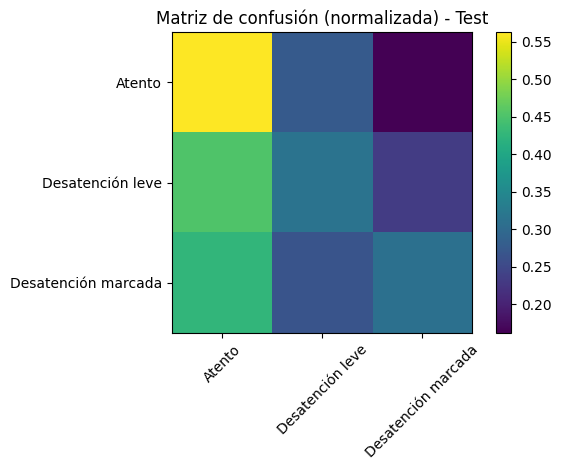

In [15]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, cohen_kappa_score)
import matplotlib.pyplot as plt

best = keras.models.load_model(f'{CKPT_DIR}/bigru_v2_best.keras')
p_test = best.predict(X_test, verbose=0).argmax(1)

TARGET_NAMES = ['Atento', 'Desatención leve', 'Desatención marcada']
print(classification_report(y_test, p_test, target_names=TARGET_NAMES, digits=3))
print("Balanced acc:", round(balanced_accuracy_score(y_test, p_test), 3))
print("Cohen kappa :", round(cohen_kappa_score(y_test, p_test), 3))

cm = confusion_matrix(y_test, p_test, normalize='true')
plt.imshow(cm); plt.colorbar()
plt.xticks(range(3), TARGET_NAMES, rotation=45); plt.yticks(range(3), TARGET_NAMES)
plt.title('Matriz de confusión (normalizada) - Test'); plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/bigru_v2_confusion_matrix.png', dpi=120)
plt.show()

### 4.3 Robustez estadística — ¿supera *con claridad* el 45,6%?

Un modelo a 46% podría no ser distinguible del trivial por ruido de muestreo. Dos verificaciones:

**(a) Intervalo de confianza bootstrap sobre la accuracy de Test.** El criterio de éxito fuerte es que el **límite inferior del IC 95% quede por encima de 45,6%**.

In [16]:
def bootstrap_ci(y_true, y_pred, metric=accuracy_score, n=2000, seed=SEED):
    rng = np.random.default_rng(seed); n_obs = len(y_true); scores = []
    for _ in range(n):
        idx = rng.integers(0, n_obs, n_obs)
        scores.append(metric(y_true[idx], y_pred[idx]))
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return np.mean(scores), lo, hi

m, lo, hi = bootstrap_ci(y_test, p_test)
print(f'Accuracy Test = {m:.3f}  IC95% [{lo:.3f}, {hi:.3f}]  (trivial = 0.456)')
print('¿Supera con claridad el trivial?', lo > 0.456)

Accuracy Test = 0.426  IC95% [0.402, 0.450]  (trivial = 0.456)
¿Supera con claridad el trivial? False


**(b) Estabilidad entre semillas.** Re-entrenar la arquitectura con ≥5 semillas y reportar **media ± desvío**. Evita conclusiones sobre un buen resultado por azar de inicialización.

> Costoso en Colab (5 entrenamientos completos de 120 épocas). Ejecutar cuando el modelo del 4.1 ya sea satisfactorio.

In [18]:
accs, f1s = [], []
for s in [0, 1, 2, 3, 4]:
    tf.random.set_seed(s); np.random.seed(s)
    m_seed = build_gru(X_train.shape[1:])
    m_seed.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=120, batch_size=64, class_weight=class_weight,
          callbacks=[MacroF1((X_val, y_val)),
                     keras.callbacks.EarlyStopping('val_macro_f1', mode='max',
                                                   patience=15, restore_best_weights=True)],
          verbose=0)
    pp = m_seed.predict(X_test, verbose=0).argmax(1)
    accs.append(accuracy_score(y_test, pp)); f1s.append(f1_score(y_test, pp, average='macro'))
print(f'Accuracy Test: {np.mean(accs):.3f} +/- {np.std(accs):.3f}')
print(f'F1 macro Test: {np.mean(f1s):.3f} +/- {np.std(f1s):.3f}')

KeyboardInterrupt: 

### 4.4 Ablation — cuantificar la contribución de cada bloque de features

Directamente al servicio de la narrativa de la tesis. Re-entrenar la misma arquitectura variando el set de entrada:

| Config | Features | Hipótesis |
|---|---|---|
| A — v1 | 5 (EAR, yaw, pitch) | Reproduce el fracaso (~37%) |
| B — +MAR | 6 | Aporte del bostezo |
| C — +blendshapes | 22 | Salto principal (gaze + AUs) |
| D — +deltas (curados) | 32 | Aporte de la dinámica/inquietud |
| E — +deltas (todas) | 44 | ¿Rinde o sobreajusta? |

Se espera que el salto grande ocurra en C (consistente con Das y Dev, 2025: los Action Units mejoran significativamente sobre landmarks+pose).

In [ ]:
# Índices de cada config sobre FEATS_FULL (22 base + 10 deltas curados = 32)
ABLATION_CONFIGS = {
    'A - v1 (EAR, yaw, pitch)':        ['ear_avg', 'yaw', 'pitch'],
    'B - +MAR':                        ['ear_avg', 'yaw', 'pitch', 'mar'],
    'C - +blendshapes (22 base)':      FEATS,                       # todas las 22 originales
    'D - +deltas curados (32)':        FEATS_FULL,                  # 22 + 10 deltas
    # 'E - +deltas todas (44)' requiere recalcular deltas sobre las 22 columnas;
    # se deja como extensión si el resultado de D no es concluyente (Opción B de 1.2).
}

def subset_cols(X, cols_all, cols_wanted):
    idx = [cols_all.index(c) for c in cols_wanted]
    return X[:, :, idx]

ablation_results = {}
for name, cols in ABLATION_CONFIGS.items():
    Xtr_a = subset_cols(X_train, FEATS_FULL, cols)
    Xva_a = subset_cols(X_val,   FEATS_FULL, cols)
    Xte_a = subset_cols(X_test,  FEATS_FULL, cols)
    m_a = build_gru(Xtr_a.shape[1:])
    m_a.fit(Xtr_a, y_train, validation_data=(Xva_a, y_val),
            epochs=120, batch_size=64, class_weight=class_weight,
            callbacks=[MacroF1((Xva_a, y_val)),
                       keras.callbacks.EarlyStopping('val_macro_f1', mode='max',
                                                     patience=15, restore_best_weights=True)],
            verbose=0)
    p_a = m_a.predict(Xte_a, verbose=0).argmax(1)
    acc_a, f1_a = accuracy_score(y_test, p_a), f1_score(y_test, p_a, average='macro')
    ablation_results[name] = {'n_features': len(cols), 'acc': acc_a, 'f1_macro': f1_a}
    print(f'{name}: n_features={len(cols)} | acc={acc_a:.3f} | f1_macro={f1_a:.3f}')

pd.DataFrame(ablation_results).T

### 4.5 Criterios de éxito (definición de "hecho")

| Nivel | Criterio | Umbral |
|---|---|---|
| **Mínimo (informativo)** | Accuracy Test > trivial | > 45,6% |
| **Sólido** | Límite inferior IC95% de accuracy sobre el trivial **y** macro-F1 > baseline | LI > 0,456 y F1 > 0,347 |
| **Objetivo** | Alineado con literatura DAiSEE | Accuracy ≳ 50%, macro-F1 ≳ 0,45 |
| **Cualitativo** | Matriz de confusión sin colapso a "Atento"; recall > 0 en las 3 clases | — |

Referencias de contexto: LSTM v1 = 36,9% / 0,347; trivial = 45,6%; Das y Dev (2025) con features enriquecidas + EfficientNet ~ 47,2% en DAiSEE.

In [ ]:
print("=== Resumen de criterios de éxito ===")
print(f"Accuracy Test:      {m:.3f}  (trivial=0.456, LSTM v1=0.369)")
print(f"IC95% accuracy:     [{lo:.3f}, {hi:.3f}]  -> supera trivial con claridad: {lo > 0.456}")
print(f"F1 macro Test:      {f1_score(y_test, p_test, average='macro'):.3f}  (baseline v1=0.347)")
nivel = 'Mínimo'
if lo > 0.456 and f1_score(y_test, p_test, average='macro') > 0.347:
    nivel = 'Sólido'
if m >= 0.50 and f1_score(y_test, p_test, average='macro') >= 0.45:
    nivel = 'Objetivo'
print(f"Nivel alcanzado: {nivel}")

## Sprint 5 — Export para Edge AI (opcional)

Coherente con el alcance de procesamiento local/cliente del proyecto.

> **Corrección respecto al plan original:** convertir directamente el modelo entrenado (con batch dinámico) a TFLite **falla** — `Bidirectional(GRU)` genera un `TensorListReserve` que TFLite Builtins no puede legalizar con `element_shape` dinámico (`batch=None`). El plan original no contemplaba esto. Hay dos soluciones:
> 1. Habilitar `SELECT_TF_OPS` (Flex delegate) — funciona pero agrega una dependencia de runtime más pesada, indeseable para un despliegue Edge/extensión de navegador liviano.
> 2. **(usada abajo)** Reconstruir un modelo de exportación idéntico con `batch_size` **fijo** (p. ej. 1) y copiarle los pesos entrenados — convierte limpio a `TFLITE_BUILTINS` puro. Verificado en este entorno: produce un `.tflite` válido sin operadores Flex.

In [ ]:
def build_gru_for_export(input_shape, n_classes=3, units=32, batch_size=1):
    """Misma arquitectura que build_gru pero con batch fijo, requerido para
    que TFLiteConverter pueda legalizar la Bidirectional(GRU) sin Flex ops."""
    inp = keras.Input(shape=input_shape, batch_size=batch_size)
    x = layers.Masking(mask_value=0.0)(inp)
    x = layers.Bidirectional(layers.GRU(units))(x)     # dropout=0 en inferencia: no hace falta especificarlo
    x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out)

export_model = build_gru_for_export(X_train.shape[1:])
export_model.set_weights(best.get_weights())   # copia los pesos del modelo entrenado (best, del Sprint 4.2)

conv = tf.lite.TFLiteConverter.from_keras_model(export_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = conv.convert()

with open(f'{CKPT_DIR}/bigru_v2.tflite', 'wb') as f:
    f.write(tflite_bytes)
print(f"TFLite exportado: {len(tflite_bytes)/1024:.1f} KB, sin operadores Flex")

# Para navegador (extensión), convertir el SavedModel de 'export_model' con:
#   tensorflowjs_converter --input_format=keras bigru_v2_export.keras web_model/
export_model.save(f'{CKPT_DIR}/bigru_v2_export.keras')

Empaquetar junto al modelo el `scaler_v2.joblib` (o sus `mean_`/`scale_` embebidos) y la lista `feature_names`: la inferencia en producción debe replicar exactamente el mismo pre-procesamiento (NaN → deltas → estandarización) que en entrenamiento.

In [ ]:
# Empaquetado final de artefactos para producción/Edge
import shutil
export_bundle = f'{CKPT_DIR}/export_bundle'
os.makedirs(export_bundle, exist_ok=True)
shutil.copy(f'{CKPT_DIR}/bigru_v2.tflite', export_bundle)
shutil.copy(f'{OUT_DIR}/scaler_v2.joblib', export_bundle)
with open(f'{export_bundle}/feature_names.json', 'w') as f:
    json.dump(FEATS_FULL, f, ensure_ascii=False, indent=2)
with open(f'{export_bundle}/preprocessing_order.json', 'w') as f:
    json.dump({
        "orden": ["interpolate_sequence (linear + ffill/bfill)", "add_deltas (10 features curadas)", "StandardScaler (fit en Train)"],
        "delta_features": DELTA_FEATURES,
        "n_frames": N_FRAMES,
    }, f, ensure_ascii=False, indent=2)
print("Bundle de export listo en:", export_bundle, "->", os.listdir(export_bundle))

## Resumen ejecutivo

La Fase 1 dejó demostrado que el cuello de botella eran las *features*, no el modelo. La Fase 2, por tanto, no reinventa la arquitectura: **(1)** consolida las 22 features nuevas tratando NaN por interpolación y derivando deltas de movimiento (→ 32 columnas), con estandarización ajustada solo en Train; **(2)** reduce la capacidad del modelo (BiGRU de 1 capa, regularizada) y valida primero con un baseline tabular que re-confirme la señal; **(3)** maneja el desbalance con *class weighting suavizado* (β=0,5) como palanca principal, con focal loss y oversampling como alternativas; **(4)** evalúa con macro-F1 como métrica primaria, selecciona sobre Validation por macro-F1 (dado su desbalance divergente) y exige que el IC95% bootstrap de la accuracy de Test supere el 45,6% del trivial, complementado con un ablation que aísla el aporte de cada bloque de features. El criterio de éxito objetivo es accuracy ≳ 50% y macro-F1 ≳ 0,45, en línea con el estado del arte reportado sobre DAiSEE.

**Cambios introducidos en este notebook respecto al `Plan_Implementacion_Fase2_Modelado.md` original** (verificados por ejecución contra datos reales y una corrida de humo completa del pipeline, incluyendo TensorFlow):
1. `interpolate_sequence` aplica `ffill().bfill()` explícito tras la interpolación lineal, para cubrir NaN en los bordes de la secuencia como ya indicaba el texto del plan (el código original no lo hacía).
2. El export a TFLite del Sprint 5 usa un modelo con `batch_size` fijo en vez de convertir directamente el modelo de entrenamiento, porque la conversión directa de `Bidirectional(GRU)` con batch dinámico falla en TFLite salvo que se habiliten Flex ops (dependencia pesada, indeseable para Edge/extensión de navegador).